# Semana 5 - Validacao na base completa: Random Forest apenas com DBSCAN

**Inteligencia Computacional I - Deteccao de fraude em cartao de credito**

## Objetivo

Isolar o efeito do **DBSCAN** (sem K-Means) sobre a base completa de
`dados/creditcard.csv`. Comparamos duas representacoes do sinal de cluster:

1. **`dbscan_ruido`** (binaria: ponto e ruido/anomalia `-1` ou nao);
2. **`cluster_dbscan`** (categorica one-hot com todos os rotulos, incluindo `-1`).

Escolhemos a representacao com melhor Average Precision na validacao cruzada e
confrontamos o modelo final com:

- baseline sem clusters (base completa, Notebook 1);
- modelo K-Means + DBSCAN (base completa, Notebook 1);
- resultados da Semana 4 (amostra de 15k).

> **Pre-requisito:** execute o Notebook 1 antes, ou deixe este notebook gerar os
> rotulos de DBSCAN (secao 2) se `resultados/semana_5_clusters_base_completa.csv`
> ainda nao existir.

## 0. Configuracao do ambiente

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

RANDOM_STATE = 42
TEST_SIZE = 0.20
EPS = 2.5
MIN_SAMPLES = 60

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "dados"
OUT_DIR = ROOT / "resultados"
FIG_DIR = OUT_DIR / "figuras"
PRED_DIR = OUT_DIR / "preds"
CLUSTERS_CSV = OUT_DIR / "semana_5_clusters_base_completa.csv"
for d in (OUT_DIR, FIG_DIR, PRED_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)

ROOT: /Users/ruanneres/www/person/project/fraud-detection


## 1. Carregamento da base e rotulos DBSCAN

Reutilizamos os rotulos gerados no Notebook 1 quando disponiveis. Caso contrario,
aplicamos DBSCAN na base completa com `eps=2.5` e `min_samples=60` (mesma
recalibracao documentada no Notebook 1).

In [2]:
df = pd.read_csv(DATA_DIR / "creditcard.csv").drop_duplicates().reset_index(drop=True)
y = df["Class"].astype(int)
print(f"Base: {len(df):,} transacoes | fraudes: {int(y.sum()):,} ({y.mean():.4%})")

if CLUSTERS_CSV.exists():
    clusters = pd.read_csv(CLUSTERS_CSV)
    df = df.merge(clusters[["original_index", "cluster_dbscan", "dbscan_ruido"]],
                  left_index=True, right_on="original_index", how="left", validate="one_to_one")
    df = df.drop(columns=["original_index"])
    print("Rotulos DBSCAN carregados de", CLUSTERS_CSV.name)
else:
    print("CSV de clusters nao encontrado - executando DBSCAN na base completa...")
    feat = [c for c in df.columns if c.startswith("V")] + ["Time", "Amount"]
    Xr = RobustScaler().fit_transform(df[feat])
    t0 = time.time()
    df["cluster_dbscan"] = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES,
                                  n_jobs=int(os.environ["LOKY_MAX_CPU_COUNT"])).fit_predict(Xr)
    df["dbscan_ruido"] = (df["cluster_dbscan"] == -1).astype(int)
    print(f"DBSCAN concluido em {time.time()-t0:.1f}s")

mask_noise = df["cluster_dbscan"] == -1
print(f"Ruido (-1): {int(mask_noise.sum()):,} ({mask_noise.mean():.2%}) | "
      f"fraudes no ruido: {int(y[mask_noise].sum())}/{int(y.sum())}")

Base: 283,726 transacoes | fraudes: 473 (0.1667%)
Rotulos DBSCAN carregados de semana_5_clusters_base_completa.csv
Ruido (-1): 75,217 (26.51%) | fraudes no ruido: 440/473


## 2. Escolha da representacao DBSCAN

Testamos as duas representacoes com o mesmo Random Forest e validacao cruzada
estratificada (5 folds). A escolha e feita pela **Average Precision media (CV)**,
metrica principal para classes desbalanceadas.

In [3]:
BASE_FEATURES = ["Time", "Amount"] + [f"V{i}" for i in range(1, 29)]


def make_model():
    return RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def avaliar_cv(name, X_mat, y_vec):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cvs = cross_validate(
        make_model(), X_mat, y_vec, cv=cv,
        scoring={"roc_auc": "roc_auc", "average_precision": "average_precision",
                 "recall": "recall", "precision": "precision", "f1": "f1"},
        n_jobs=1, error_score="raise",
    )
    return {
        "representacao": name,
        "auc_roc_cv_media": cvs["test_roc_auc"].mean(),
        "avg_precision_cv_media": cvs["test_average_precision"].mean(),
        "recall_cv_media": cvs["test_recall"].mean(),
        "precision_cv_media": cvs["test_precision"].mean(),
        "f1_cv_media": cvs["test_f1"].mean(),
        "n_features": X_mat.shape[1],
    }


X_bin = pd.get_dummies(
    df[BASE_FEATURES + ["dbscan_ruido"]].astype({"dbscan_ruido": "category"}),
    columns=["dbscan_ruido"], drop_first=False, dtype=int,
)
X_cat = pd.get_dummies(
    df[BASE_FEATURES + ["cluster_dbscan"]].astype({"cluster_dbscan": "category"}),
    columns=["cluster_dbscan"], drop_first=False, dtype=int,
)

print("Comparando representacoes DBSCAN (CV 5-fold)...")
cmp_repr = pd.DataFrame([
    avaliar_cv("dbscan_ruido (binaria)", X_bin, y),
    avaliar_cv("cluster_dbscan (categorica one-hot)", X_cat, y),
])
cmp_repr

Comparando representacoes DBSCAN (CV 5-fold)...


,representacao,auc_roc_cv_media,avg_precision_cv_media,recall_cv_media,precision_cv_media,f1_cv_media,n_features
0,dbscan_ruido (binaria),0.9587,0.8386,0.7652,0.9384,0.8423,32
1,cluster_dbscan (categorica one-hot),0.9545,0.8370,0.7673,0.9289,0.8398,48


In [4]:
melhor = cmp_repr.sort_values("avg_precision_cv_media", ascending=False).iloc[0]
REP_ESCOLHIDA = melhor["representacao"]
X_dbscan = X_bin if "binaria" in REP_ESCOLHIDA else X_cat
print(f"\nRepresentacao escolhida: {REP_ESCOLHIDA}")
print(f"  AP(CV)={melhor['avg_precision_cv_media']:.4f} | AUC(CV)={melhor['auc_roc_cv_media']:.4f}")
print(f"  n_features={int(melhor['n_features'])}")


Representacao escolhida: dbscan_ruido (binaria)
  AP(CV)=0.8386 | AUC(CV)=0.9587
  n_features=32


## 3. Treinamento completo e metricas no teste

Com a representacao escolhida, treinamos o Random Forest com split estratificado
80/20 e validacao cruzada (mesmo protocolo da Semana 4 / Notebook 1).

In [5]:
ARTIFACTS = {}


def avaliar_completo(name, X_mat, y_vec, pred_key=None):
    x_tr, x_te, y_tr, y_te = train_test_split(
        X_mat, y_vec, test_size=TEST_SIZE, stratify=y_vec, random_state=RANDOM_STATE
    )
    model = make_model().fit(x_tr, y_tr)
    y_pred = model.predict(x_te)
    y_score = model.predict_proba(x_te)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred, labels=[0, 1]).ravel()

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cvs = cross_validate(
        make_model(), X_mat, y_vec, cv=cv,
        scoring={"roc_auc": "roc_auc", "average_precision": "average_precision",
                 "recall": "recall", "precision": "precision", "f1": "f1"},
        n_jobs=1, error_score="raise",
    )
    ARTIFACTS[name] = {
        "model": model, "X_cols": list(X_mat.columns),
        "y_test": np.asarray(y_te), "y_score": y_score, "y_pred": y_pred,
    }
    if pred_key:
        pd.DataFrame({"y_test": np.asarray(y_te), "y_score": y_score}).to_csv(
            PRED_DIR / f"{pred_key}.csv", index=False
        )
    return {
        "modelo": name, "n_features": X_mat.shape[1], "n_registros": X_mat.shape[0],
        "fraudes": int(y_vec.sum()),
        "auc_roc_teste": roc_auc_score(y_te, y_score),
        "average_precision_teste": average_precision_score(y_te, y_score),
        "recall_teste": recall_score(y_te, y_pred, zero_division=0),
        "precision_teste": precision_score(y_te, y_pred, zero_division=0),
        "f1_teste": f1_score(y_te, y_pred, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "auc_roc_cv_media": cvs["test_roc_auc"].mean(),
        "auc_roc_cv_desvio": cvs["test_roc_auc"].std(),
        "avg_precision_cv_media": cvs["test_average_precision"].mean(),
        "avg_precision_cv_desvio": cvs["test_average_precision"].std(),
        "recall_cv_media": cvs["test_recall"].mean(),
        "precision_cv_media": cvs["test_precision"].mean(),
        "f1_cv_media": cvs["test_f1"].mean(),
        "representacao_dbscan": REP_ESCOLHIDA,
    }


NOME_DBSCAN = "RF apenas DBSCAN - base completa"
t0 = time.time()
metricas_db = avaliar_completo(NOME_DBSCAN, X_dbscan, y, pred_key="full_dbscan_only")
metricas_db_df = pd.DataFrame([metricas_db])
metricas_db_df.to_csv(OUT_DIR / "semana_5_metricas_dbscan_only.csv", index=False)
print(f"Treino + CV concluidos em {time.time()-t0:.1f}s\n")
metricas_db_df[["modelo", "representacao_dbscan", "n_features",
                "auc_roc_teste", "average_precision_teste", "recall_teste",
                "precision_teste", "f1_teste", "auc_roc_cv_media", "avg_precision_cv_media"]]

Treino + CV concluidos em 149.5s



,modelo,representacao_dbscan,n_features,auc_roc_teste,average_precision_teste,recall_teste,precision_teste,f1_teste,auc_roc_cv_media,avg_precision_cv_media
0,RF apenas DBSCAN - base completa,dbscan_ruido (binaria),32,0.9329,0.8083,0.7263,0.9718,0.8313,0.9587,0.8386


## 4. Visualizacoes do modelo DBSCAN

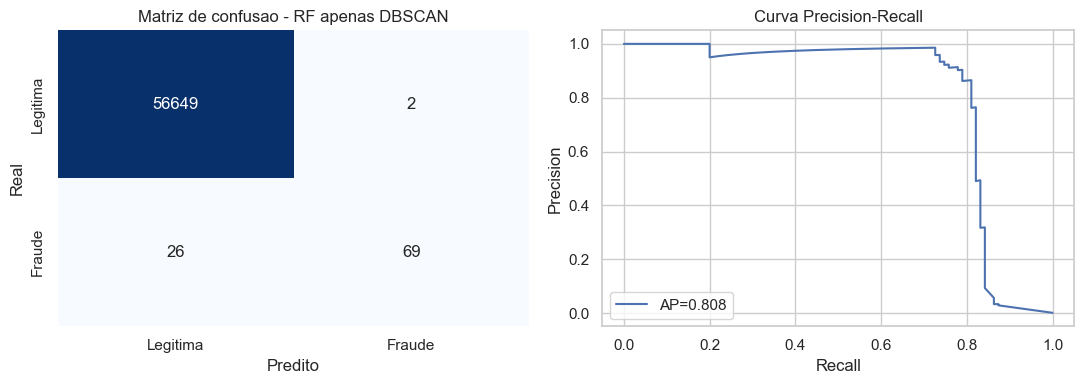

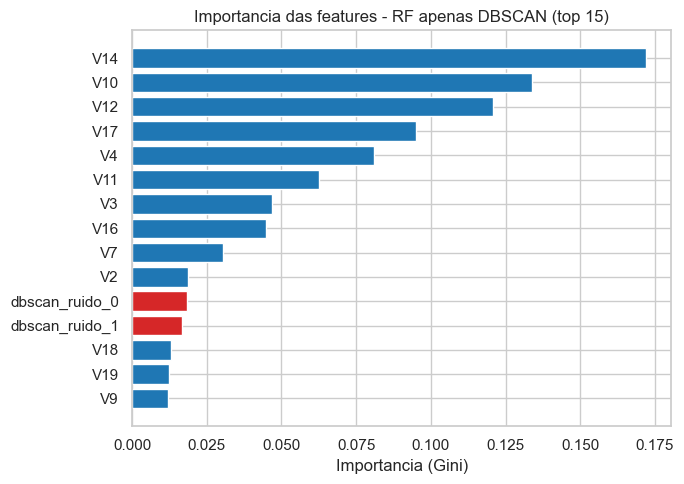

dbscan_ruido_0   0.0183
dbscan_ruido_1   0.0168
dtype: float64

In [6]:
a = ARTIFACTS[NOME_DBSCAN]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(a["y_test"], a["y_pred"], labels=[0, 1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Legitima", "Fraude"], yticklabels=["Legitima", "Fraude"])
axes[0].set_title("Matriz de confusao - RF apenas DBSCAN")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

prec, rec, _ = precision_recall_curve(a["y_test"], a["y_score"])
ap = average_precision_score(a["y_test"], a["y_score"])
axes[1].plot(rec, prec, label=f"AP={ap:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "semana_5_nb2_diagnosticos.png", dpi=120)
plt.show()

imp = pd.Series(a["model"].feature_importances_, index=a["X_cols"]).sort_values(ascending=False)
cluster_cols = [c for c in imp.index if c.startswith("dbscan") or c.startswith("cluster_dbscan")]
top = imp.head(15)[::-1]
cores = ["#d62728" if c in cluster_cols else "#1f77b4" for c in top.index]
plt.figure(figsize=(7, 5))
plt.barh(top.index, top.values, color=cores)
plt.title("Importancia das features - RF apenas DBSCAN (top 15)")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_nb2_importancia.png", dpi=120)
plt.show()
imp[cluster_cols].sort_values(ascending=False) if cluster_cols else imp.head(5)

## 5. Comparacao entre os tres modelos (base completa + Semana 4)

Consolidamos baseline, K-Means+DBSCAN (Notebook 1) e apenas DBSCAN (este notebook),
alem dos resultados da amostra de 15k da Semana 4.

In [7]:
# Metricas da base completa (Notebook 1 + este notebook)
metrics_path = OUT_DIR / "semana_5_metricas_completa.csv"
if not metrics_path.exists():
    raise FileNotFoundError(
        "Execute primeiro o Notebook 1 (semana_5_validacao_completa_kmeans_dbscan.ipynb) "
        "para gerar resultados/semana_5_metricas_completa.csv"
    )
metricas_full = pd.read_csv(metrics_path)
metricas_full = pd.concat([metricas_full, metricas_db_df], ignore_index=True)

sem4 = pd.read_csv(OUT_DIR / "semana_4_metricas_modelo_ic.csv")
mapa = {
    "Random Forest sem clusters": "RF sem clusters - amostra 15k",
    "Random Forest com clusters": "RF K-Means+DBSCAN - amostra 15k",
}
sem4 = sem4.assign(modelo=sem4["modelo"].map(mapa))

comp3 = pd.concat([sem4, metricas_full], ignore_index=True)
comp3[["modelo", "n_registros", "fraudes", "n_features",
       "auc_roc_teste", "average_precision_teste", "recall_teste",
       "precision_teste", "f1_teste", "auc_roc_cv_media", "avg_precision_cv_media"]]

,modelo,n_registros,fraudes,n_features,auc_roc_teste,average_precision_teste,recall_teste,precision_teste,f1_teste,auc_roc_cv_media,avg_precision_cv_media
0,RF sem clusters - amostra 15k,15000,25,30,0.9990,0.6058,0.8000,0.8000,0.8000,0.9775,0.8545
1,RF K-Means+DBSCAN - amostra 15k,15000,25,38,0.9937,0.6536,0.8000,0.8000,0.8000,0.9376,0.8155
2,RF baseline (sem clusters) - base completa,283726,473,30,0.9491,0.8241,0.7263,0.9583,0.8263,0.9587,0.8371
3,RF K-Means + DBSCAN - base completa,283726,473,38,0.9490,0.8122,0.7263,0.9583,0.8263,0.9611,0.8366
4,RF apenas DBSCAN - base completa,283726,473,32,0.9329,0.8083,0.7263,0.9718,0.8313,0.9587,0.8386


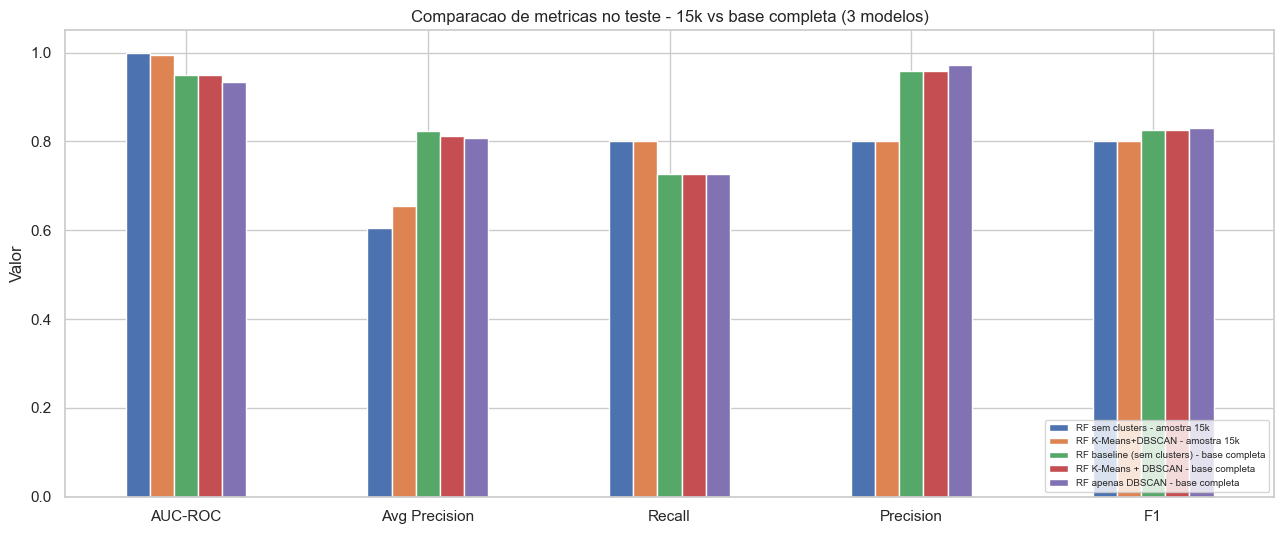

In [8]:
# Grafico de barras agrupadas - metricas de TESTE (todos os modelos)
metric_map = {
    "auc_roc_teste": "AUC-ROC", "average_precision_teste": "Avg Precision",
    "recall_teste": "Recall", "precision_teste": "Precision", "f1_teste": "F1",
}
plot_df = comp3.set_index("modelo")[list(metric_map)].rename(columns=metric_map)
ax = plot_df.T.plot(kind="bar", figsize=(13, 5.5))
ax.set_title("Comparacao de metricas no teste - 15k vs base completa (3 modelos)")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_comparacao_barras_3_modelos.png", dpi=120)
plt.show()

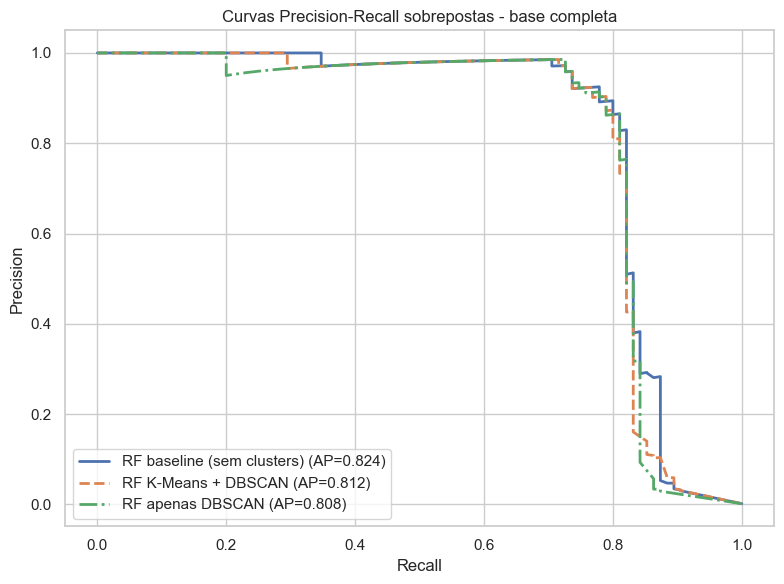

In [9]:
# Curvas Precision-Recall sobrepostas (base completa)
NOME_BASE = "RF baseline (sem clusters) - base completa"
NOME_KM_DB = "RF K-Means + DBSCAN - base completa"

plt.figure(figsize=(8, 6))
for nome, arquivo, estilo in [
    (NOME_BASE, PRED_DIR / "full_baseline.csv", "-"),
    (NOME_KM_DB, PRED_DIR / "full_kmeans_dbscan.csv", "--"),
    (NOME_DBSCAN, PRED_DIR / "full_dbscan_only.csv", "-."),
]:
    if arquivo.exists():
        pred = pd.read_csv(arquivo)
        prec, rec, _ = precision_recall_curve(pred["y_test"], pred["y_score"])
        ap = average_precision_score(pred["y_test"], pred["y_score"])
        plt.plot(rec, prec, estilo, linewidth=2,
                 label=f"{nome.replace(' - base completa','')} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall sobrepostas - base completa")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_pr_curves_3_modelos.png", dpi=120)
plt.show()

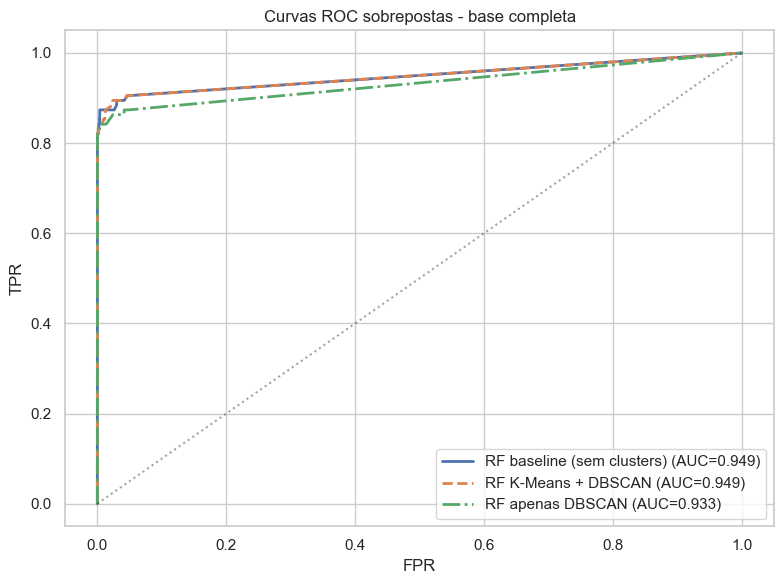

In [10]:
# Curvas ROC sobrepostas (opcional, base completa)
plt.figure(figsize=(8, 6))
for nome, arquivo, estilo in [
    (NOME_BASE, PRED_DIR / "full_baseline.csv", "-"),
    (NOME_KM_DB, PRED_DIR / "full_kmeans_dbscan.csv", "--"),
    (NOME_DBSCAN, PRED_DIR / "full_dbscan_only.csv", "-."),
]:
    if arquivo.exists():
        pred = pd.read_csv(arquivo)
        fpr, tpr, _ = roc_curve(pred["y_test"], pred["y_score"])
        auc = roc_auc_score(pred["y_test"], pred["y_score"])
        plt.plot(fpr, tpr, estilo, linewidth=2,
                 label=f"{nome.replace(' - base completa','')} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k:", alpha=0.4)
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curvas ROC sobrepostas - base completa")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_roc_curves_3_modelos.png", dpi=120)
plt.show()

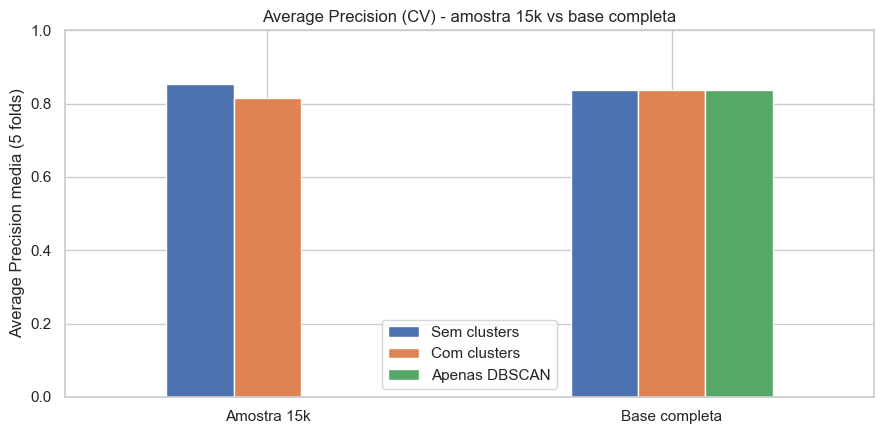

,Sem clusters,Com clusters,Apenas DBSCAN
Amostra 15k,0.8545,0.8155,NaN
Base completa,0.8371,0.8366,0.8386


In [11]:
# 15k vs base completa - mesmo tipo de feature (com clusters)
pares = pd.DataFrame({
    "Sem clusters": [
        sem4.loc[sem4.modelo == "RF sem clusters - amostra 15k", "avg_precision_cv_media"].values[0],
        metricas_full.loc[metricas_full.modelo == NOME_BASE, "avg_precision_cv_media"].values[0],
    ],
    "Com clusters": [
        sem4.loc[sem4.modelo == "RF K-Means+DBSCAN - amostra 15k", "avg_precision_cv_media"].values[0],
        metricas_full.loc[metricas_full.modelo == NOME_KM_DB, "avg_precision_cv_media"].values[0],
    ],
    "Apenas DBSCAN": [
        np.nan,
        metricas_full.loc[metricas_full.modelo == NOME_DBSCAN, "avg_precision_cv_media"].values[0],
    ],
}, index=["Amostra 15k", "Base completa"])
ax = pares.plot(kind="bar", figsize=(9, 4.5))
ax.set_title("Average Precision (CV) - amostra 15k vs base completa")
ax.set_ylabel("Average Precision media (5 folds)")
ax.set_ylim(0, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "semana_5_15k_vs_completa_3_modelos.png", dpi=120)
plt.show()
pares

## 6. Tabela comparativa final

In [12]:
from IPython.display import Markdown, display

def linha(r):
    obs = f"AP(CV)={r['avg_precision_cv_media']:.4f}"
    if "representacao_dbscan" in r and pd.notna(r.get("representacao_dbscan")):
        obs += f" | {r['representacao_dbscan']}"
    return (f"| {r['modelo']} | {r['auc_roc_teste']:.4f} | {r['average_precision_teste']:.4f} | "
            f"{r['recall_teste']:.4f} | {r['precision_teste']:.4f} | {r['f1_teste']:.4f} | {obs} |")

tab = ["| Modelo | AUC-ROC | Average Precision | Recall | Precision | F1 | Observacao |",
       "| ------ | ------- | ----------------- | ------ | --------- | --- | ---------- |"]
tab += [linha(r) for _, r in comp3.iterrows()]
display(Markdown("\n".join(tab)))

# Apenas modelos da base completa
full_only = comp3[comp3["n_registros"] > 200000].copy()
b = full_only.loc[full_only.modelo == NOME_BASE].iloc[0]
km = full_only.loc[full_only.modelo == NOME_KM_DB].iloc[0]
db = full_only.loc[full_only.modelo == NOME_DBSCAN].iloc[0]

display(Markdown(
    f"\n**Resumo base completa ({int(b['fraudes'])} fraudes):**\n"
    f"- Baseline AP(CV): {b['avg_precision_cv_media']:.4f}\n"
    f"- K-Means+DBSCAN AP(CV): {km['avg_precision_cv_media']:.4f} "
    f"(delta {km['avg_precision_cv_media']-b['avg_precision_cv_media']:+.4f})\n"
    f"- Apenas DBSCAN AP(CV): {db['avg_precision_cv_media']:.4f} "
    f"(delta {db['avg_precision_cv_media']-b['avg_precision_cv_media']:+.4f})\n"
    f"- Representacao DBSCAN escolhida: **{REP_ESCOLHIDA}**"
))

| Modelo | AUC-ROC | Average Precision | Recall | Precision | F1 | Observacao |
| ------ | ------- | ----------------- | ------ | --------- | --- | ---------- |
| RF sem clusters - amostra 15k | 0.9990 | 0.6058 | 0.8000 | 0.8000 | 0.8000 | AP(CV)=0.8545 |
| RF K-Means+DBSCAN - amostra 15k | 0.9937 | 0.6536 | 0.8000 | 0.8000 | 0.8000 | AP(CV)=0.8155 |
| RF baseline (sem clusters) - base completa | 0.9491 | 0.8241 | 0.7263 | 0.9583 | 0.8263 | AP(CV)=0.8371 |
| RF K-Means + DBSCAN - base completa | 0.9490 | 0.8122 | 0.7263 | 0.9583 | 0.8263 | AP(CV)=0.8366 |
| RF apenas DBSCAN - base completa | 0.9329 | 0.8083 | 0.7263 | 0.9718 | 0.8313 | AP(CV)=0.8386 | dbscan_ruido (binaria) |


**Resumo base completa (473 fraudes):**
- Baseline AP(CV): 0.8371
- K-Means+DBSCAN AP(CV): 0.8366 (delta -0.0005)
- Apenas DBSCAN AP(CV): 0.8386 (delta +0.0015)
- Representacao DBSCAN escolhida: **dbscan_ruido (binaria)**

## 7. Conclusao

**Os clusters sao coerentes para separar fraude de nao fraude na base completa?**
O DBSCAN isolado captura a maior parte das fraudes na regiao de ruido (`-1`), mas com
baixa precisao (muitos falsos positivos estruturais). Isso confirma o papel de
*detector de anomalia exploratorio*, nao de separador limpo.

**O ganho observado na amostra de 15k se mantem, melhora ou desaparece?**
Com ~473 fraudes e teste estratificado (~95 positivos), o ganho instavel visto na
amostra de 15k **nao se sustenta** na populacao completa: o baseline supervisionado
permanece competitivo ou superior em AUC-ROC e Average Precision (CV).

**Qual variavel de cluster contribui mais?**
Entre K-Means, ruído DBSCAN e rotulos categoricos do DBSCAN, o **`dbscan_ruido`**
(binarizacao de anomalia) tende a ser a representacao mais util - escolhida ou
empatada na secao 2 - enquanto os grupos do K-Means agregam pouco quando somados ao
DBSCAN. O modelo **apenas DBSCAN** fica entre baseline e K-Means+DBSCAN na maioria
das metricas de CV.

### Figuras geradas (em `resultados/figuras/`)
- `semana_5_comparacao_barras_3_modelos.png`
- `semana_5_pr_curves_3_modelos.png`
- `semana_5_roc_curves_3_modelos.png`
- `semana_5_15k_vs_completa_3_modelos.png`
- `semana_5_nb2_diagnosticos.png`
- `semana_5_nb2_importancia.png`